# Auditoría de candidatos de la prediction pool

Vista de lectura del ranking reproducible. La selección, el consenso RRF,
el crossmatch SIMBAD y las disposiciones se calculan en
`wr_detector.pipelines.prediction_pool_candidates`.

In [1]:
from pathlib import Path
from IPython.display import Markdown, display
import duckdb
import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "pyproject.toml").exists()
)
CANDIDATE_DB = PROJECT_ROOT / "data/databases/prediction_pool_candidates.duckdb"
POOL_DB = PROJECT_ROOT / "data/databases/prediction_pool_exact_union_v1.duckdb"
if not CANDIDATE_DB.exists():
    raise FileNotFoundError(CANDIDATE_DB)

with duckdb.connect(str(CANDIDATE_DB), read_only=True) as con:
    run = con.execute("SELECT * FROM candidate_review_runs").fetchdf()
    models = con.execute("SELECT * FROM candidate_models").fetchdf()
    model_ranks = con.execute("SELECT * FROM candidate_model_ranks").fetchdf()
    consensus = con.execute(
        "SELECT * FROM candidate_consensus ORDER BY consensus_rank LIMIT 500"
    ).fetchdf()
    review = con.execute(
        "SELECT * FROM candidate_review ORDER BY consensus_rank"
    ).fetchdf()
    recommendations = con.execute(
        "SELECT * FROM candidate_recommendations ORDER BY followup_rank"
    ).fetchdf()
with duckdb.connect(str(POOL_DB), read_only=True) as con:
    pool_status = con.execute(
        '''
        SELECT b.status,
               COUNT(*) FILTER (WHERE t.status='completed') AS completed_tiles,
               SUM(t.acquired_pre_locus) AS acquired_rows,
               SUM(t.accepted_union) AS accepted_union,
               SUM(t.known_excluded) AS known_excluded,
               SUM(t.written) AS eligible_rows
        FROM exact_union_builds b
        JOIN exact_union_tiles t USING (pool_build_id)
        GROUP BY b.status
        '''
    ).fetchdf()

## tl;dr

In [2]:
headline = recommendations.head(5)
display(Markdown(
    f"- Pool: **{int(pool_status.iloc[0]['completed_tiles'])}/675 tiles**, "
    f"estado **{pool_status.iloc[0]['status']}**.\n"
    f"- Ranking: **{len(model_ranks):,}** filas top-K y "
    f"**{len(review):,}** candidatos enriquecidos.\n"
    f"- SIMBAD: **{int(review['match_found'].sum())}** coincidencias entre "
    f"{len(review)} candidatos.\n"
    f"- Seguimiento: **{len(recommendations)}** objetos revisados; "
    f"los primeros cinco se muestran al final."
))

- Pool: **675/675 tiles**, estado **completed**.
- Ranking: **50,000** filas top-K y **500** candidatos enriquecidos.
- SIMBAD: **331** coincidencias entre 500 candidatos.
- Seguimiento: **20** objetos revisados; los primeros cinco se muestran al final.

## Context & Methods

### Key Assumptions

- Los scores son valores de ordenamiento, no probabilidades calibradas.
- El consenso usa Reciprocal Rank Fusion (`k=60`) con pesos iguales.
- Una ausencia de SIMBAD no demuestra que el objeto sea desconocido.
- La confirmación de una estrella WR continúa siendo espectroscópica.

## Data

In [3]:
display(pool_status)
display(run.T.rename(columns={0: "valor"}))
model_metric_columns = [
    "role",
    "result_id",
    "dataset_variant",
    "model",
    "sampler",
    "wr_holdout",
    "holdout_average_precision",
    "holdout_precision_at_50",
    "holdout_recall_at_50",
    "holdout_precision_at_100",
    "holdout_recall_at_100",
    "holdout_recall_at_fpr_0p001",
    "threshold_calibration_negative_pass_rate",
    "overfit_risk_score",
]
display(
    models[model_metric_columns]
    .sort_values("holdout_average_precision", ascending=False)
    .reset_index(drop=True)
)
display(
    model_ranks.groupby(
        ["role", "result_id", "dataset_variant", "model"], as_index=False
    ).agg(
        rows=("source_id", "size"),
        score_min=("score", "min"),
        score_max=("score", "max"),
    )
)

,status,completed_tiles,acquired_rows,accepted_union,known_excluded,eligible_rows
0,completed,675,185135016.0,65010724.0,32345.0,64978379.0


,valor
review_run_id,candidate_review_v3_main_top5_v1
scoring_run_id,score_run_v3_main_top5_v1
model_run_id,run_v3_main
pool_build_id,pool_exact_union_acquisition_v1
config_path,E:\Proyectos\Wolf-Rayet-Detector\configs\predi...
config_sha256,7a841b5b6968dc1513511a0cd1083caaf05479e67df891...
selected_result_ids_json,"[""9e08cb4f7517ab76d5b152e7a7dc53e02c826321"", ""..."
per_model_limit,10000
review_limit,500
deep_review_limit,20


,role,result_id,dataset_variant,model,sampler,wr_holdout,holdout_average_precision,holdout_precision_at_50,holdout_recall_at_50,holdout_precision_at_100,holdout_recall_at_100,holdout_recall_at_fpr_0p001,threshold_calibration_negative_pass_rate,overfit_risk_score
0,average_precision_leader,49957d2295543512d384313f5c352a619fac7be8,relaxed_photometry,xgboost,smote,68,0.567085,0.70,0.514706,0.43,0.632353,0.367647,0.006011,2.020034
1,estimator_diversity,9275e7d7da706b3ada8ea1f8c05dae6b833417d1,relaxed_photometry,hist_gradient_boosting,none,68,0.536962,0.68,0.500000,0.45,0.661765,0.235294,0.003615,3.042971
2,accepted_stable,2efb4b2059dac012e52b9ff3f11e17fe4995dc66,strict_poe_2,xgboost,smote,42,0.536202,0.44,0.523810,0.31,0.738095,0.309524,0.004722,0.731253
3,broad_shortlist,9e08cb4f7517ab76d5b152e7a7dc53e02c826321,relaxed_photometry,xgboost,none,68,0.534980,0.68,0.500000,0.48,0.705882,0.308824,0.005086,4.053412
4,strict_photometry_counterpart,84e88df5ea4d32863d5a2918648af8fbf63ec034,strict_photometry,xgboost,none,62,0.524154,0.60,0.483871,0.44,0.709677,0.209677,0.004865,2.350878


,role,result_id,dataset_variant,model,rows,score_min,score_max
0,accepted_stable,2efb4b2059dac012e52b9ff3f11e17fe4995dc66,strict_poe_2,xgboost,10000,0.881531,0.999947
1,average_precision_leader,49957d2295543512d384313f5c352a619fac7be8,relaxed_photometry,xgboost,10000,0.992152,0.999724
2,broad_shortlist,9e08cb4f7517ab76d5b152e7a7dc53e02c826321,relaxed_photometry,xgboost,10000,0.996512,0.999992
3,estimator_diversity,9275e7d7da706b3ada8ea1f8c05dae6b833417d1,relaxed_photometry,hist_gradient_boosting,10000,0.961634,0.994846
4,strict_photometry_counterpart,84e88df5ea4d32863d5a2918648af8fbf63ec034,strict_photometry,xgboost,10000,0.996221,0.999989


## Results

In [4]:
top_sets = {
    result_id: set(group.nsmallest(500, "model_rank")["source_id"])
    for result_id, group in model_ranks.groupby("result_id")
}
labels = {
    result_id: group["role"].iloc[0]
    for result_id, group in model_ranks.groupby("result_id")
}
overlap = pd.DataFrame(index=top_sets, columns=top_sets, dtype=float)
for left, left_ids in top_sets.items():
    for right, right_ids in top_sets.items():
        union = left_ids | right_ids
        overlap.loc[left, right] = len(left_ids & right_ids) / len(union) if union else 0
overlap = overlap.rename(index=labels, columns=labels)
display(overlap.style.format("{:.1%}").background_gradient(cmap="magma"))

,accepted_stable,average_precision_leader,strict_photometry_counterpart,estimator_diversity,broad_shortlist
accepted_stable,100.0%,6.2%,9.8%,12.4%,8.1%
average_precision_leader,6.2%,100.0%,9.9%,17.9%,23.5%
strict_photometry_counterpart,9.8%,9.9%,100.0%,6.0%,7.1%
estimator_diversity,12.4%,17.9%,6.0%,100.0%,12.9%
broad_shortlist,8.1%,23.5%,7.1%,12.9%,100.0%


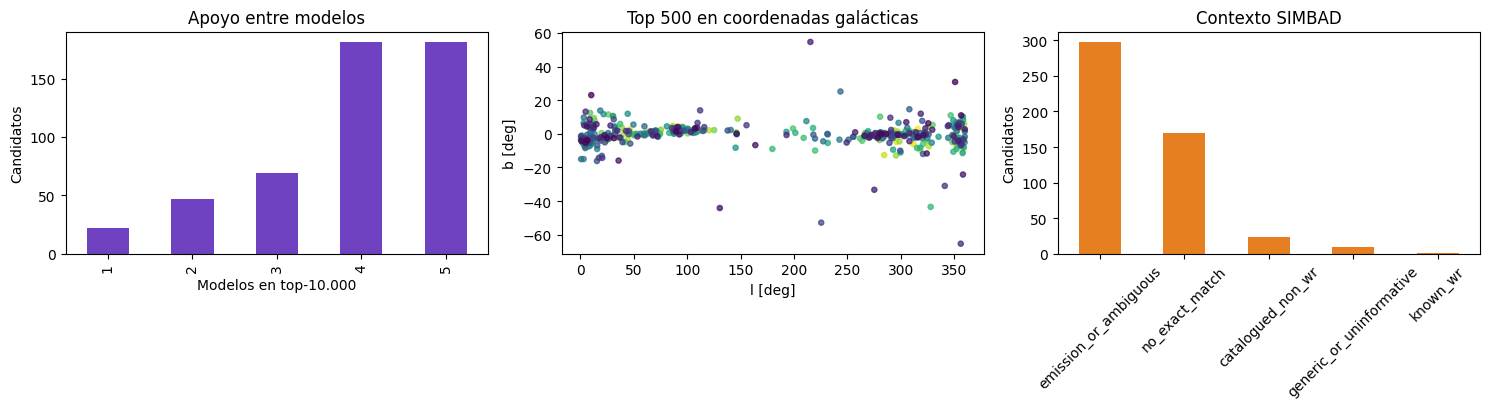

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
review["model_support"].value_counts().sort_index().plot.bar(
    ax=axes[0], color="#6f42c1"
)
axes[0].set(
    title="Apoyo entre modelos",
    xlabel="Modelos en top-10.000",
    ylabel="Candidatos",
)
axes[1].scatter(
    review["galactic_l"],
    review["galactic_b"],
    c=review["consensus_rank"],
    s=14,
    cmap="viridis_r",
    alpha=0.75,
)
axes[1].set(
    title="Top 500 en coordenadas galácticas",
    xlabel="l [deg]",
    ylabel="b [deg]",
)
review["review_disposition"].value_counts().plot.bar(
    ax=axes[2], color="#e67e22"
)
axes[2].set(title="Contexto SIMBAD", xlabel="", ylabel="Candidatos")
axes[2].tick_params(axis="x", rotation=45)
fig.tight_layout()
plt.show()

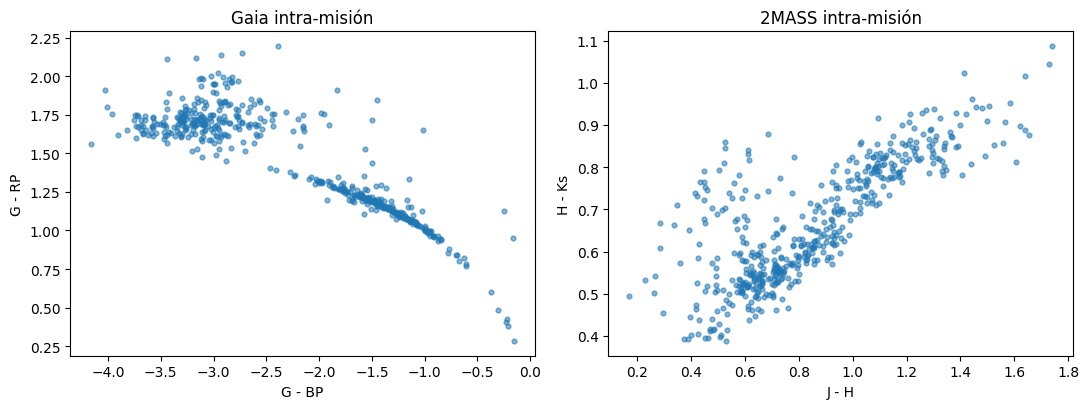

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].scatter(review["G_BP"], review["G_RP"], s=12, alpha=0.55)
axes[0].set(title="Gaia intra-misión", xlabel="G - BP", ylabel="G - RP")
axes[1].scatter(review["J_H"], review["H_K"], s=12, alpha=0.55)
axes[1].set(title="2MASS intra-misión", xlabel="J - H", ylabel="H - Ks")
fig.tight_layout()
plt.show()

In [7]:
review_columns = [
    "followup_rank",
    "consensus_rank",
    "source_id",
    "model_support",
    "variant_support",
    "best_model_rank",
    "G",
    "BP_RP",
    "J_K",
    "W1_W2",
    "parallax_over_error",
    "ruwe",
    "halpha_ew",
    "espels_class",
    "simbad_main_id",
    "simbad_main_type",
    "review_disposition",
    "review_comment",
    "simbad_url",
    "gaia_url",
    "gaia_adql",
]
display(recommendations[review_columns].head(20))

,followup_rank,consensus_rank,source_id,model_support,variant_support,best_model_rank,G,BP_RP,J_K,W1_W2,...,ruwe,halpha_ew,espels_class,simbad_main_id,simbad_main_type,review_disposition,review_comment,simbad_url,gaia_url,gaia_adql
0,1,1,2166202734689148672,5,3,1,14.622931,2.587146,1.188,0.408,...,0.999612,-1.988389,HerbigStar,2MASS J21131875+5045157,LP*,emission_or_ambiguous,Apoyo de 5 modelos; mejor rango individual 1. ...,https://simbad.cds.unistra.fr/simbad/sim-id?Id...,https://gea.esac.esa.int/archive/,SELECT * FROM gaiadr3.gaia_source WHERE source...
1,2,2,5350650917143854848,5,3,5,14.967538,2.957835,1.554,0.400,...,1.046731,-1.073106,NaN,[MDN2017] VPHAS OB1 03426,Em*,emission_or_ambiguous,Apoyo de 5 modelos; mejor rango individual 5. ...,https://simbad.cds.unistra.fr/simbad/sim-id?Id...,https://gea.esac.esa.int/archive/,SELECT * FROM gaiadr3.gaia_source WHERE source...
2,3,3,5891636442187092864,5,3,5,14.266089,2.994689,1.201,0.347,...,1.029239,-0.050540,NaN,2MASS J14295505-5727556,*,generic_or_uninformative,Apoyo de 5 modelos; mejor rango individual 5. ...,https://simbad.cds.unistra.fr/simbad/sim-id?Id...,https://gea.esac.esa.int/archive/,SELECT * FROM gaiadr3.gaia_source WHERE source...
3,4,4,5334656111016518784,5,3,2,12.442915,2.129945,1.176,0.460,...,1.087835,-4.114467,HerbigStar,WRAY 15-920,LP?,emission_or_ambiguous,Apoyo de 5 modelos; mejor rango individual 2. ...,https://simbad.cds.unistra.fr/simbad/sim-id?Id...,https://gea.esac.esa.int/archive/,SELECT * FROM gaiadr3.gaia_source WHERE source...
4,5,6,5334941782225424128,5,3,9,15.037809,2.487490,1.241,0.408,...,0.977682,-3.202808,HerbigStar,NaN,,no_exact_match,Apoyo de 5 modelos; mejor rango individual 9. ...,https://simbad.cds.unistra.fr/simbad/sim-id?Id...,https://gea.esac.esa.int/archive/,SELECT * FROM gaiadr3.gaia_source WHERE source...
5,6,7,5972467245662845312,5,3,1,14.041367,3.017813,1.191,0.412,...,0.938837,-1.537155,NaN,NaN,,no_exact_match,Apoyo de 5 modelos; mejor rango individual 1. ...,https://simbad.cds.unistra.fr/simbad/sim-id?Id...,https://gea.esac.esa.int/archive/,SELECT * FROM gaiadr3.gaia_source WHERE source...
6,7,8,5308462587266411392,5,3,28,14.254772,2.194408,1.215,0.375,...,1.085535,-1.838426,beStar,NaN,,no_exact_match,Apoyo de 5 modelos; mejor rango individual 28....,https://simbad.cds.unistra.fr/simbad/sim-id?Id...,https://gea.esac.esa.int/archive/,SELECT * FROM gaiadr3.gaia_source WHERE source...
7,8,9,5258784281093855488,5,3,7,14.436081,2.704706,1.320,0.418,...,1.076620,-2.453268,HerbigStar,UCAC4 165-042925,*,generic_or_uninformative,Apoyo de 5 modelos; mejor rango individual 7. ...,https://simbad.cds.unistra.fr/simbad/sim-id?Id...,https://gea.esac.esa.int/archive/,SELECT * FROM gaiadr3.gaia_source WHERE source...
8,9,11,2199609540072016256,5,3,18,14.241659,2.226296,1.171,0.416,...,1.062339,-3.088971,beStar,2MASS J22102009+5833325,Y*?,emission_or_ambiguous,Apoyo de 5 modelos; mejor rango individual 18....,https://simbad.cds.unistra.fr/simbad/sim-id?Id...,https://gea.esac.esa.int/archive/,SELECT * FROM gaiadr3.gaia_source WHERE source...
9,10,12,445434635982458880,5,3,11,14.156094,2.452224,1.225,0.366,...,1.029775,-1.295067,HerbigStar,NaN,,no_exact_match,Apoyo de 5 modelos; mejor rango individual 11....,https://simbad.cds.unistra.fr/simbad/sim-id?Id...,https://gea.esac.esa.int/archive/,SELECT * FROM gaiadr3.gaia_source WHERE source...


## Takeaways

In [8]:
display(Markdown(
    "Los cinco objetos siguientes son prioridades de seguimiento, no "
    "confirmaciones WR. Se excluyeron del ranking de seguimiento los WR ya "
    "conocidos y las clasificaciones no-WR inequívocas, conservando siempre "
    "su rango consenso original para auditoría."
))
display(headline[review_columns].head(5))

Los cinco objetos siguientes son prioridades de seguimiento, no confirmaciones WR. Se excluyeron del ranking de seguimiento los WR ya conocidos y las clasificaciones no-WR inequívocas, conservando siempre su rango consenso original para auditoría.

,followup_rank,consensus_rank,source_id,model_support,variant_support,best_model_rank,G,BP_RP,J_K,W1_W2,...,ruwe,halpha_ew,espels_class,simbad_main_id,simbad_main_type,review_disposition,review_comment,simbad_url,gaia_url,gaia_adql
0,1,1,2166202734689148672,5,3,1,14.622931,2.587146,1.188,0.408,...,0.999612,-1.988389,HerbigStar,2MASS J21131875+5045157,LP*,emission_or_ambiguous,Apoyo de 5 modelos; mejor rango individual 1. ...,https://simbad.cds.unistra.fr/simbad/sim-id?Id...,https://gea.esac.esa.int/archive/,SELECT * FROM gaiadr3.gaia_source WHERE source...
1,2,2,5350650917143854848,5,3,5,14.967538,2.957835,1.554,0.400,...,1.046731,-1.073106,NaN,[MDN2017] VPHAS OB1 03426,Em*,emission_or_ambiguous,Apoyo de 5 modelos; mejor rango individual 5. ...,https://simbad.cds.unistra.fr/simbad/sim-id?Id...,https://gea.esac.esa.int/archive/,SELECT * FROM gaiadr3.gaia_source WHERE source...
2,3,3,5891636442187092864,5,3,5,14.266089,2.994689,1.201,0.347,...,1.029239,-0.050540,NaN,2MASS J14295505-5727556,*,generic_or_uninformative,Apoyo de 5 modelos; mejor rango individual 5. ...,https://simbad.cds.unistra.fr/simbad/sim-id?Id...,https://gea.esac.esa.int/archive/,SELECT * FROM gaiadr3.gaia_source WHERE source...
3,4,4,5334656111016518784,5,3,2,12.442915,2.129945,1.176,0.460,...,1.087835,-4.114467,HerbigStar,WRAY 15-920,LP?,emission_or_ambiguous,Apoyo de 5 modelos; mejor rango individual 2. ...,https://simbad.cds.unistra.fr/simbad/sim-id?Id...,https://gea.esac.esa.int/archive/,SELECT * FROM gaiadr3.gaia_source WHERE source...
4,5,6,5334941782225424128,5,3,9,15.037809,2.487490,1.241,0.408,...,0.977682,-3.202808,HerbigStar,NaN,,no_exact_match,Apoyo de 5 modelos; mejor rango individual 9. ...,https://simbad.cds.unistra.fr/simbad/sim-id?Id...,https://gea.esac.esa.int/archive/,SELECT * FROM gaiadr3.gaia_source WHERE source...
